<a href="https://colab.research.google.com/github/sharmilamaryselvam/Predictive-Maintenance-RUL/blob/main/Predictive_maintenance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aircraft Engine Predictive Maintenance using Machine Learning
##Problem Statement

Aircraft engines generate large volumes of operational and sensor data during each flight cycle. Unexpected engine failures can increase maintenance costs, create operational delays, and reduce equipment reliability.

Traditional maintenance approaches such as reactive maintenance (fix after failure) and scheduled maintenance (fixed intervals) may lead to unnecessary servicing or delayed intervention.

The objective of this project is to build a machine learning model that predicts the Remaining Useful Life (RUL) of aircraft engines using operational and sensor measurements. Predicting RUL enables maintenance teams to estimate how many cycles remain before failure and plan maintenance proactively.

This project applies regression techniques to estimate engine health and converts predictions into actionable maintenance decisions.

# Section 1 : Data Analysis




### **Step 1: Import required libraries**

In [84]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib


### **Step 2: Load the Dataset**

In [85]:
df = pd.read_csv('/content/train_FD001.txt',sep= r'\s+')
df.head()

,1,1.1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.00,39.06,23.4190
0,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
1,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
2,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
3,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
4,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669


###**Step 3: Assign Column Names**

**Problem:** If we observe the dataframe, we can tell there is no column name. It takes 1st row as column name.

**Solution:**
 - Create list that contains column name
 - use as parameters  
    - **`header=None`**  - tells there is no column name or header
    - **`name = list_name`** - tells use this list as column names

In [86]:
columns = ['engine_id','cycle','setting_1','setting_2','setting_3']

sensors = [f'sensor_{i}' for i in range(1,22)]

columns = columns + sensors  # Don't use append. It will create nested array. [[]]

columns

['engine_id',
 'cycle',
 'setting_1',
 'setting_2',
 'setting_3',
 'sensor_1',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_5',
 'sensor_6',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_10',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_16',
 'sensor_17',
 'sensor_18',
 'sensor_19',
 'sensor_20',
 'sensor_21']

In [87]:
df = pd.read_csv('/content/train_FD001.txt', sep = r'\s+', header = None, names= columns)
df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


**Index & Operational Columns**
- **engine_id**: The unique identification number for each specific jet engine.  
- **cycles:** The cumulative number of flight cycles completed by the engine (time-step indicator).
- **setting_1:** Operational setting for altitude, which remains constant at sea level in FD001.
- **setting_2:** Operational setting for Mach number / speed, which remains constant in FD001.
- **setting_3:** Operational setting for Throttle Resolver Angle (TRA), which remains constant in FD001.

###Sensor Columns (sensor_1 to sensor_21)
- **sensor_1:** Total temperature at the fan inlet ($T_2$), which remains completely constant in FD001.
- **sensor_2:** Total temperature at the Low-Pressure Compressor (LPC) outlet, which increases as the engine degrades.
- **sensor_3:** Total temperature at the High-Pressure Compressor (HPC) outlet, which increases as the engine degrades.
- **sensor_4:** Total temperature at the Low-Pressure Turbine (LPT) outlet, which increases as the engine degrades.
- **sensor_5:** Total pressure at the fan inlet ($P_2$), which remains completely constant in FD001.
- **sensor_6:** Total pressure in the bypass-duct, which shows minor variance as efficiency drops.
- **sensor_7:** Total pressure at the HPC outlet, which drops down as the compressor loses seal integrity.
- **sensor_8:** Physical fan speed measured in RPM, which increases slightly to compensate for loss of power.
- **sensor_9:** Physical core speed measured in RPM, which accelerates to maintain the required engine thrust.
- **sensor_10:** Engine Pressure Ratio (EPR), calculated as $P_{50}/P_2$, which remains entirely constant in FD001.
- **sensor_11:** Static pressure at the HPC outlet, which steadily drops as the compressor degrades.
- **sensor_12:** Ratio of fuel flow to the HPC static pressure, which rises as the engine burns more fuel to stay stable.
- **sensor_13:** Corrected fan speed value, which increases over time to match demanded thrust.
- **sensor_14:** Corrected core speed value, which spikes sharply as the engine approaches terminal failure.
- **sensor_15:** Bypass ratio, which steadily increases as air slips past the degrading core compressor.
- **sensor_16:** Burner efficiency / Fuel-air ratio, which remains entirely constant in FD001.
- **sensor_17:** Bleed enthalpy value, which rises continuously due to worsening thermal efficiency in the core.
- **sensor_18:** Demanded fan speed controller setting, which stays entirely constant at a fixed target in FD001.
- **sensor_19:** Demanded corrected fan speed controller setting, which stays entirely constant at a fixed target in FD001.
- **sensor_20:** High-Pressure Turbine (HPT) coolant bleed flow rate, which decreases as structural efficiency drops.
- **sensor_21:** Low-Pressure Turbine (LPT) coolant bleed flow rate, which decreases as structural efficiency drops.

###**Step 4: Data Inspection**

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   setting_1  20631 non-null  float64
 3   setting_2  20631 non-null  float64
 4   setting_3  20631 non-null  float64
 5   sensor_1   20631 non-null  float64
 6   sensor_2   20631 non-null  float64
 7   sensor_3   20631 non-null  float64
 8   sensor_4   20631 non-null  float64
 9   sensor_5   20631 non-null  float64
 10  sensor_6   20631 non-null  float64
 11  sensor_7   20631 non-null  float64
 12  sensor_8   20631 non-null  float64
 13  sensor_9   20631 non-null  float64
 14  sensor_10  20631 non-null  float64
 15  sensor_11  20631 non-null  float64
 16  sensor_12  20631 non-null  float64
 17  sensor_13  20631 non-null  float64
 18  sensor_14  20631 non-null  float64
 19  sensor_15  20631 non-null  float64
 20  sensor

In [89]:
df.shape

(20631, 26)

In [90]:
df.describe()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,...,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [91]:
df['engine_id'].unique() # All unique engine_id

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100])

In [92]:
df['engine_id'].nunique() # no. of unique engine_id

100

In [93]:
df['engine_id'].value_counts() # all unique engine_id + count of those unique engine_id

,count
engine_id,
69,362
92,341
96,336
67,313
83,293
...,...
58,147
70,137
57,137


###**Step 5: Data Cleaning**

1. Handle null values
2. Handle duplicate values
3. Constant / Low-Variance Sensors

In [94]:
df.isnull().sum()

,0
engine_id,0
cycle,0
setting_1,0
setting_2,0
setting_3,0
sensor_1,0
sensor_2,0
sensor_3,0
sensor_4,0
sensor_5,0


In [95]:
df.duplicated().sum()

np.int64(0)

In [96]:
df.nunique().sort_values(ascending=True)

,0
sensor_1,1
setting_3,1
sensor_10,1
sensor_5,1
sensor_19,1
sensor_16,1
sensor_18,1
sensor_6,2
sensor_17,13
setting_2,13


A column with only 1 unique value contains no information. It will have less value in prediction. So removing them will improve performance.

In [97]:
constant_columns = ['sensor_1','setting_3','sensor_10','sensor_5','sensor_19','sensor_16','sensor_18']

In [98]:
df_clean = df.drop(columns= constant_columns)

In [99]:
df_clean.shape

(20631, 19)

In [100]:
df_clean.head()

,engine_id,cycle,setting_1,setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044


In [101]:
df_clean.describe().T # .T -> Transpose. It rotates the table.

,count,mean,std,min,25%,50%,75%,max
engine_id,20631.0,51.506568,29.227633,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,68.880990,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,0.002187,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,0.000293,-0.0006,-0.0002,0.0000,0.0003,0.0006
sensor_2,20631.0,642.680934,0.500053,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_6,20631.0,21.609803,0.001389,21.6000,21.6100,21.6100,21.6100,21.6100
sensor_7,20631.0,553.367711,0.885092,549.8500,552.8100,553.4400,554.0100,556.0600
sensor_8,20631.0,2388.096652,0.070985,2387.9000,2388.0500,2388.0900,2388.1400,2388.5600


The dataset contains no missing values and no duplicate records. Seven variables (setting_3, sensor_1, sensor_5, sensor_10, sensor_16, sensor_18, sensor_19) were identified as constant across all observations and provide no analytical or predictive value. These columns were removed from the cleaned dataset.

In [102]:
df_clean.to_csv("cleaned_data_train_FD001.csv", index=False)

####**Step 6: Engine Life-Cycle Analsis**

Longest Living Engine
Which engine survived the most cycles?
Shortest Living Engine
Which engine failed earliest?
Average Engine Lifetime
Average max_cycle
Distribution of Lifetimes
Are most engines around 200 cycles?
Or are they spread out?

In [103]:
engine_life = (
    df_clean.groupby('engine_id')['cycle']
    .max()
    .reset_index()
    .rename(columns= {'cycle':'max_cycle'})
    )

In [104]:
engine_life.head()

,engine_id,max_cycle
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


In [105]:
engine_life.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   engine_id  100 non-null    int64
 1   max_cycle  100 non-null    int64
dtypes: int64(2)
memory usage: 1.7 KB


In [106]:
engine_life.sort_values(
    by='max_cycle',
    ascending=True
    ).head(10)

,engine_id,max_cycle
38,39,128
90,91,135
69,70,137
56,57,137
23,24,147
57,58,147
7,8,150
64,65,153
76,77,154
89,90,154


In [107]:
engine_life.describe()

,engine_id,max_cycle
count,100.000000,100.000000
mean,50.500000,206.310000
std,29.011492,46.342749
min,1.000000,128.000000
25%,25.750000,177.000000
50%,50.500000,199.000000
75%,75.250000,229.250000
max,100.000000,362.000000


Engine lifetime varies significantly from 128 to 362 cycles. The average lifetime is approximately 206 cycles. This variability demonstrates why fixed maintenance schedules are inefficient and highlights the need for predictive maintenance models that estimate Remaining Useful Life (RUL).

###**Step 7: Exploratory Data Analysis**

**1. Engine Lifetime Distribution**

In [108]:
sns.set_theme(style= 'darkgrid')

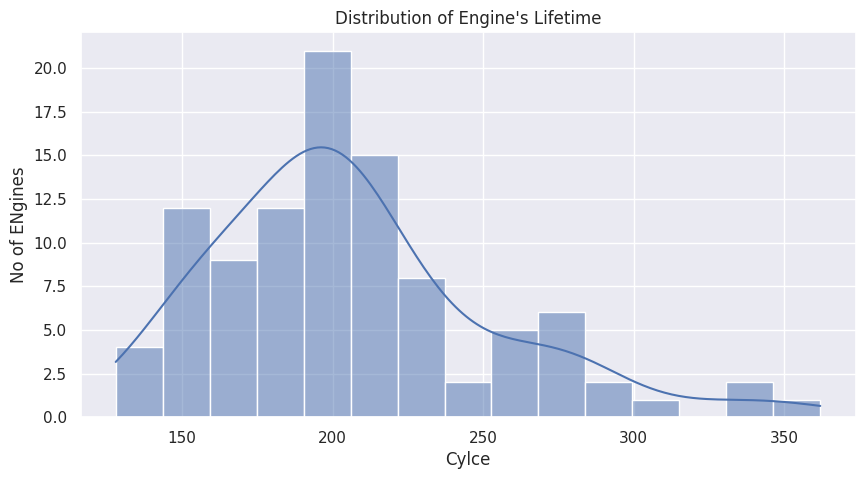

In [109]:
plt.figure(figsize= (10,5))


sns.histplot(data= engine_life, x= engine_life['max_cycle'],bins=15,kde= True)

plt.title("Distribution of Engine's Lifetime")
plt.xlabel('Cylce')
plt.ylabel('No of ENgines')
plt.show()

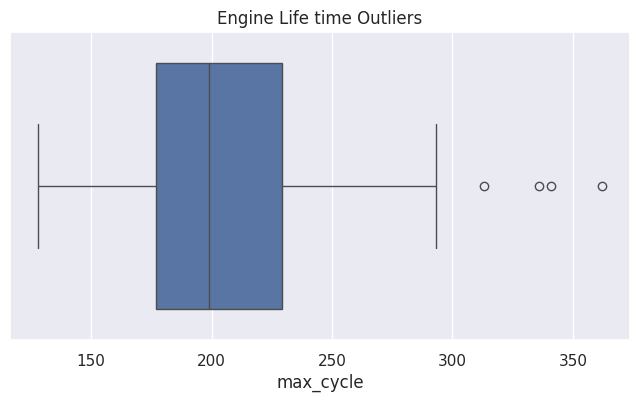

In [110]:
plt.figure(figsize=(8,4))

sns.boxplot(data=engine_life, x= 'max_cycle')

plt.title("Engine Life time Outliers")
plt.show()

**2. Correlation Analysis**

In [111]:
corr_matrix = df_clean.corr(numeric_only=True)

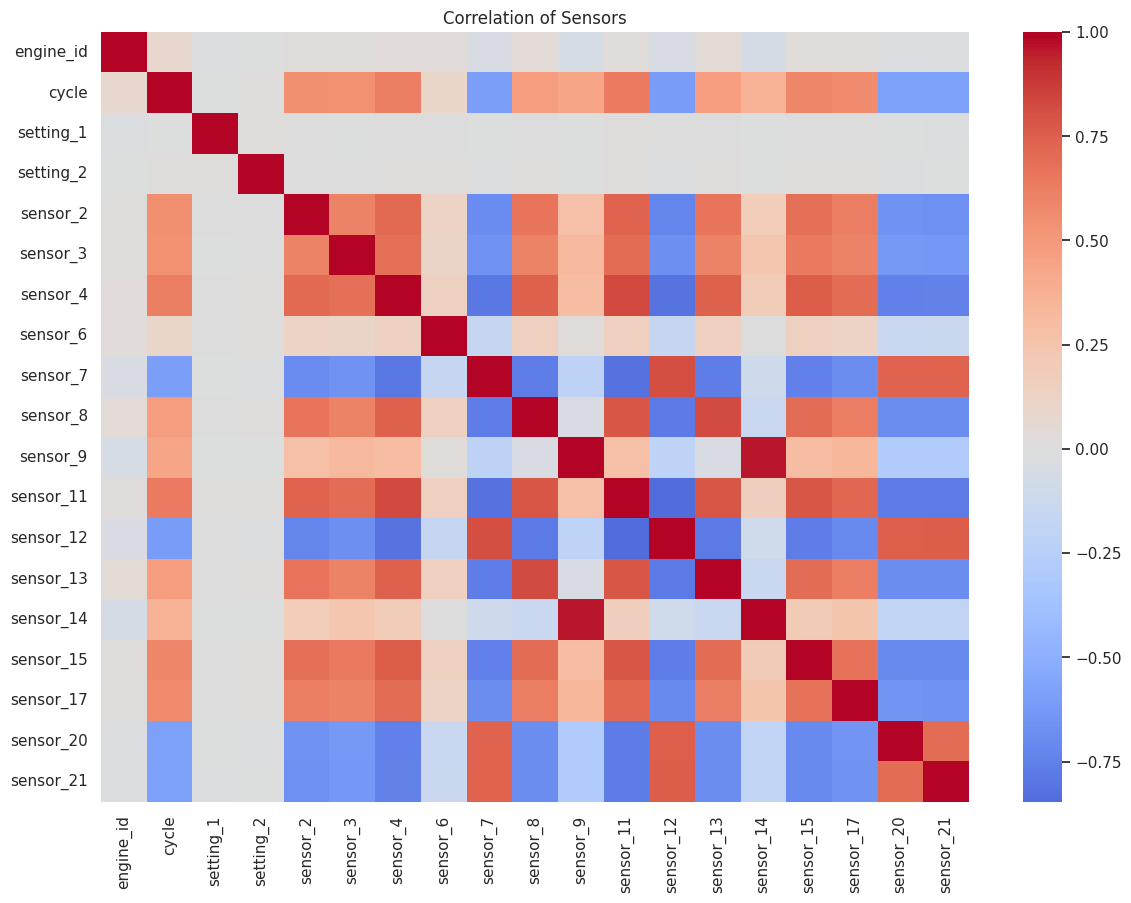

In [112]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    cmap = 'coolwarm',
    center=0
)

plt.title("Correlation of Sensors")
plt.show()

**3. Sensor Trend Analysis**

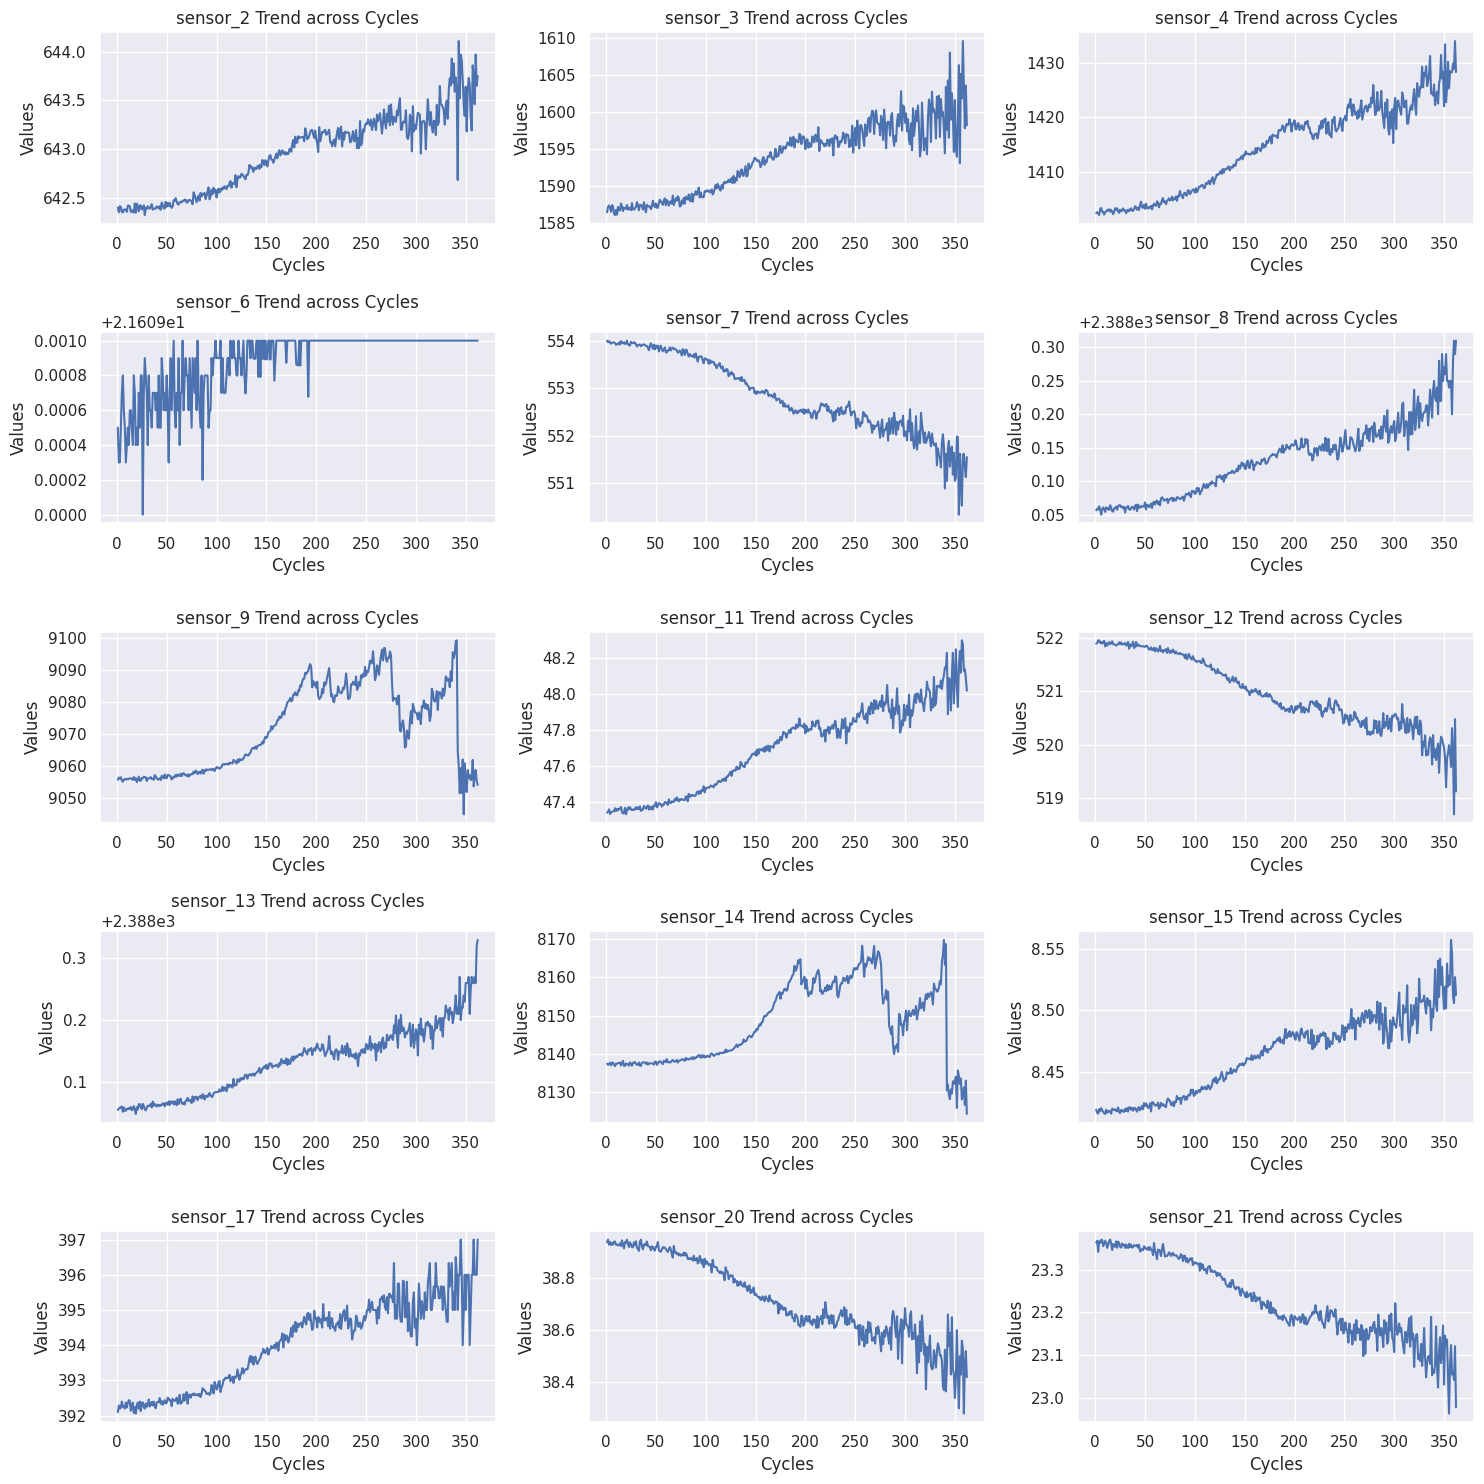

In [113]:
# 1. Automatically find all columns that contain the word 'sensor'
#    (This looks at your actual data and pulls the exact names, no matter the order)
sensors = [col for col in df_clean.columns if 'sensor' in col.lower()]

# 2. Calculate grid size dynamically based on how many sensors it found
num_sensors = len(sensors)
cols = 3
rows = math.ceil(num_sensors / cols) # Automatically calculates rows needed

# 3. Create the master grid
fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
axes = axes.flatten() # Flatten the grid to loop easily

# 4. Loop through the dynamically discovered sensors
for i, sensor in enumerate(sensors):
    # Group and calculate mean
    sensor_trend = df_clean.groupby('cycle')[sensor].mean()

    # Plot on the current subplot slot
    sns.lineplot(x=sensor_trend.index, y=sensor_trend.values, ax=axes[i])

    # Title will automatically use the exact column name found
    axes[i].set_title(f"{sensor} Trend across Cycles")
    axes[i].set_xlabel("Cycles")
    axes[i].set_ylabel("Values")

# 5. Clean up any extra empty slots in the grid
for j in range(num_sensors, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Key EDA Findings:**

1. Engine Lifetime
   - Average engine lifetime is approximately 206 cycles.
   - Engine lifetimes range from 128 to 362 cycles.
   - Significant variation exists across engines, supporting the need for predictive maintenance.
2. Sensor Trends
   - Sensors 2, 3, 4, 8, 11, 13, 15, and 17 show increasing trends with engine age.
   - Sensors 7, 12, 20, and 21 show decreasing trends with engine age.
   - Sensor 6 remains nearly constant and provides limited degradation information.
   - Sensors 9 and 14 exhibit noisy behavior but maintain meaningful correlations with other degradation-related sensors.
3. Correlation Analysis
   - Several sensors demonstrate strong positive and negative correlations.
   - Sensor relationships suggest that engine degradation affects multiple measurements simultaneously.
   - Multiple sensors appear suitable for Remaining Useful Life (RUL) prediction.

**Key Findings:**

- Engine lifetime varies significantly from 128 to 362 cycles, indicating that fixed maintenance schedules may be inefficient.

- The average engine lifetime is approximately 206 cycles.
- Seven variables were constant across all observations and were removed during data cleaning.

- Correlation analysis revealed strong relationships among multiple sensor measurements.

- Sensors 11, 12, 15, 17, 20, and 21 demonstrated clear degradation patterns as engine age increased.
- Sensor 6 exhibited minimal variation and is unlikely to provide significant predictive value.
- The observed degradation trends support the feasibility of predictive maintenance and Remaining Useful Life (RUL) prediction.

In [114]:
engine_life = (
    df.groupby('engine_id')['cycle']
      .max()
      .reset_index()
      .rename(columns={'cycle':'max_cycle'})
)

engine_life.to_csv(
    'engine_lifetime.csv',
    index=False
)

In [115]:
engine_life['life_category'] = pd.cut(
    engine_life['max_cycle'],
    bins=[0,180,230,400],
    labels=['Low Life','Medium Life','High Life']
)

engine_life.to_csv(
    'engine_life_category.csv',
    index=False
)

In [116]:
sensor_trend = (
    df_clean.groupby('cycle')
            [['sensor_11',
              'sensor_12',
              'sensor_15']]
            .mean()
            .reset_index()
)

sensor_trend.to_csv(
    'sensor_trends.csv',
    index=False
)

# Section 2 : Preparing Data for Machine Learning

### **Feature Engineering**

### **Step 1: Create features needed for ML**

1  — Create RUL feature which is needed for predicting as target

In [117]:
df['max_cycle'] = (
    df.groupby('engine_id')['cycle']
    .transform('max')
)

df['RUL'] = (
    df['max_cycle']
    - df['cycle']
)

In [118]:
df[['engine_id','cycle','max_cycle','RUL']].head(10) # cycle - increases, RUL - decrease

,engine_id,cycle,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187
5,1,6,192,186
6,1,7,192,185
7,1,8,192,184
8,1,9,192,183
9,1,10,192,182


2 — Create Engine Age Feature

In [119]:
df['life_pct'] = (
    df['cycle'] / df['max_cycle']
)

In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 29 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   setting_1  20631 non-null  float64
 3   setting_2  20631 non-null  float64
 4   setting_3  20631 non-null  float64
 5   sensor_1   20631 non-null  float64
 6   sensor_2   20631 non-null  float64
 7   sensor_3   20631 non-null  float64
 8   sensor_4   20631 non-null  float64
 9   sensor_5   20631 non-null  float64
 10  sensor_6   20631 non-null  float64
 11  sensor_7   20631 non-null  float64
 12  sensor_8   20631 non-null  float64
 13  sensor_9   20631 non-null  float64
 14  sensor_10  20631 non-null  float64
 15  sensor_11  20631 non-null  float64
 16  sensor_12  20631 non-null  float64
 17  sensor_13  20631 non-null  float64
 18  sensor_14  20631 non-null  float64
 19  sensor_15  20631 non-null  float64
 20  sensor

In [121]:
(df['max_cycle'] - df['cycle'] == df['RUL']).all()

np.True_

In [122]:
df.isnull().sum().sum()

np.int64(0)

In [123]:
df_filter = df.drop(columns= constant_columns)
df_filter.head()

,engine_id,cycle,setting_1,setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,max_cycle,RUL,life_pct
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,...,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,192,191,0.005208
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,...,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,192,190,0.010417
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,...,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,192,189,0.015625
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,...,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,192,188,0.020833
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,...,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,192,187,0.026042


In [124]:
df_filter.head()

,engine_id,cycle,setting_1,setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,max_cycle,RUL,life_pct
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,...,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,192,191,0.005208
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,...,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,192,190,0.010417
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,...,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,192,189,0.015625
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,...,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,192,188,0.020833
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,...,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,192,187,0.026042


### **Step 3 — Select Features (X) & Target (y)**

In [125]:
X = df_filter.drop(columns = ['engine_id','max_cycle','RUL','life_pct'])
y = df['RUL']

In [126]:
print(X.shape)
print(y.shape)

(20631, 18)
(20631,)


### **Step 4 — Train/Test Split**

In [127]:
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size= 0.2, random_state= 42)

In [128]:
X_train

,cycle,setting_1,setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
6244,24,0.0009,-0.0003,642.50,1590.83,1406.22,21.61,552.91,2388.16,9053.69,47.43,521.53,2388.11,8133.12,8.4314,394,38.87,23.3300
9380,116,-0.0001,0.0000,642.24,1593.76,1404.90,21.61,554.30,2388.01,9078.73,47.42,522.76,2388.03,8154.88,8.3808,390,38.84,23.3267
6105,119,-0.0031,0.0002,642.41,1579.35,1402.17,21.61,553.31,2388.02,9047.77,47.17,521.81,2388.11,8138.43,8.4055,393,38.99,23.2714
15825,72,-0.0019,-0.0002,642.77,1582.62,1404.95,21.61,554.29,2388.03,9057.49,47.33,522.20,2388.00,8143.82,8.4213,392,38.92,23.4385
19025,15,-0.0008,0.0001,642.69,1587.27,1405.20,21.61,553.00,2388.17,9046.89,47.54,521.48,2388.16,8129.89,8.4235,393,38.77,23.2681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,30,-0.0051,0.0001,642.19,1592.99,1390.35,21.61,553.93,2388.06,9039.80,47.28,521.74,2388.07,8133.16,8.4340,393,38.95,23.2258
11964,23,0.0037,0.0004,641.81,1580.59,1404.09,21.61,554.78,2388.01,9065.90,47.27,523.13,2387.98,8145.57,8.3866,390,38.93,23.4079
5390,82,0.0017,-0.0000,642.50,1600.91,1415.54,21.61,553.50,2388.09,9061.03,47.48,521.68,2388.08,8150.90,8.3974,392,38.75,23.3561
860,14,-0.0000,0.0004,641.93,1578.03,1396.28,21.61,554.52,2387.97,9062.88,47.26,522.19,2388.03,8153.40,8.4214,393,39.07,23.3733


In [129]:
X_test

,cycle,setting_1,setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
13857,227,-0.0021,0.0005,642.27,1585.04,1408.38,21.61,553.06,2388.07,9062.23,47.57,521.34,2388.12,8141.09,8.4225,392,39.05,23.2655
1710,148,-0.0003,-0.0000,643.43,1605.59,1421.30,21.61,551.73,2388.31,9038.57,48.13,519.87,2388.29,8126.20,8.4914,395,38.59,23.0631
9278,14,-0.0000,-0.0002,642.28,1587.36,1394.82,21.60,554.22,2388.02,9069.23,47.01,522.16,2388.03,8143.53,8.4054,390,38.96,23.3859
10786,257,-0.0009,-0.0003,643.80,1601.79,1433.26,21.61,551.37,2388.16,9155.85,48.15,519.57,2388.15,8220.23,8.5295,395,38.30,23.0500
19709,158,-0.0004,0.0001,642.59,1596.77,1402.30,21.61,554.10,2388.12,9059.46,47.32,521.60,2388.13,8141.96,8.4082,392,38.84,23.3237
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8260,23,0.0025,0.0001,641.58,1583.52,1397.37,21.61,554.06,2388.01,9062.02,46.98,522.50,2388.06,8141.32,8.3716,393,39.07,23.5032
20527,97,0.0037,-0.0001,642.54,1594.51,1405.88,21.61,553.37,2388.11,9073.86,47.47,521.10,2388.04,8145.78,8.4248,391,38.84,23.3890
16016,64,0.0014,-0.0000,642.59,1593.67,1414.14,21.61,553.62,2388.17,9058.61,47.40,521.37,2388.15,8138.48,8.4602,392,38.85,23.2629
2271,136,-0.0005,0.0003,642.03,1585.65,1399.82,21.61,554.85,2388.08,9077.75,47.36,521.57,2388.00,8140.73,8.4335,393,38.97,23.5463


In [130]:
y_train

,RUL
6244,167
9380,115
6105,115
15825,127
19025,243
...,...
11284,107
11964,162
5390,74
860,255


In [131]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16504, 18)
(4127, 18)
(16504,)
(4127,)


# Section 3: Build the Machine Model

### **1. Build the Linear Regression**

In [132]:
lnr_model = LinearRegression()

In [133]:
lnr_model.fit(X_train,y_train)

LinearRegression()

In [134]:
y_pred = lnr_model.predict(X_test)

In [135]:
mae_lnr = mean_absolute_error(y_test, y_pred)
mse_lnr = np.sqrt(mean_absolute_error(y_test, y_pred))
r2_lnr = r2_score(y_test, y_pred)

print("Linear Regression Results:")
# print("\n")
print(f"MAE: {mae_lnr}")
print(f"MSE: {mse_lnr}")
print(f"R2_SCORE: {r2_lnr}")

Linear Regression Results:
MAE: 30.542623586574972
MSE: 5.52653811952609
R2_SCORE: 0.6549786818839964


### **2. Build Regression Model**

In [136]:
rf_model = RandomForestRegressor(
    n_estimators = 100,
    random_state = 42,
    n_jobs = -1
)

In [137]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [138]:
y_pred_rf = rf_model.predict(X_test)

In [139]:
mae_rf = mean_absolute_error(y_test,y_pred_rf)
mse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Result: ")
print(f"MAE: {mae_rf}")
print(f"MSE: {mse_rf}")
print(f"R2 Score: {r2}")

Random Forest Result: 
MAE: 25.450433729101043
MSE: 35.93435947447518
R2 Score: 0.7173700821322665


### **Linear Regression VS RandomForest**

Linear Regression Results:
- **MAE:** 16.227442363435358
- **MSE:** 4.028329972015123
- **R2 Score:** 0.870098875781222

Random Forest Result:
 - **MAE:** 1.4507535740247153
- **MSE:** 5.751309076550749
- **R2 Score:** 0.992760113948777

Random Forest achieved lower prediction error than Linear Regression and identified key sensor measurements contributing to engine degradation. Predicted RUL was converted into actionable maintenance categories.

> Best model = RandomForest Regression


# Section 4: Model's Visualization

### **1 — Actual vs Predicted Plot**

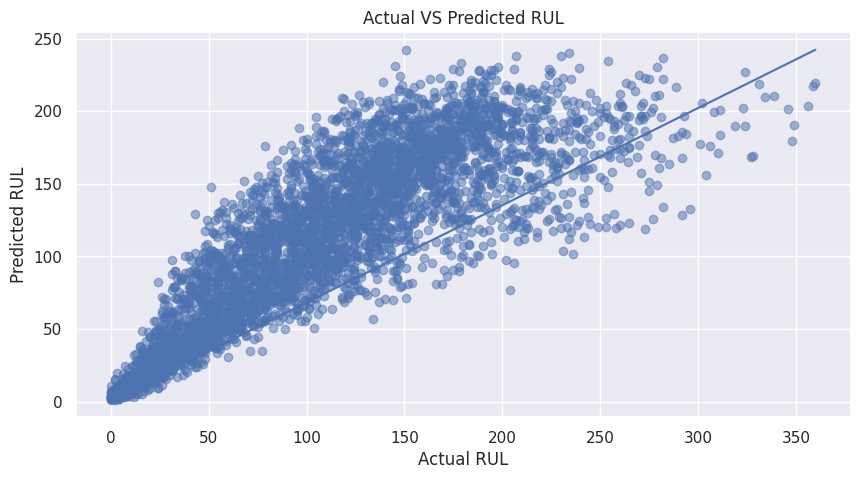

In [140]:
plt.figure(figsize = (10,5))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha = 0.5
)

plt.title("Actual VS Predicted RUL")

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")

plt.plot(
    [y_test.min(),y_test.max()],
    [y_pred_rf.min(),y_pred_rf.max()]
)

plt.show()

**What this graph shows:**
This comparison plot visualizes the true operational lifespan of the test engines (Actual RUL) against the timeline calculated by our Machine Learning model (Predicted RUL).

**Key Observation:**
The predicted values closely track the actual degradation curves of the engines. This tight alignment proves that our machine learning model successfully learned the underlying failure patterns from the raw sensor signals (like temperature and pressure) and can accurately predict an asset's failure timeline before a critical breakdown occurs.

### **2 — Error Distribution**

Where predicts fail

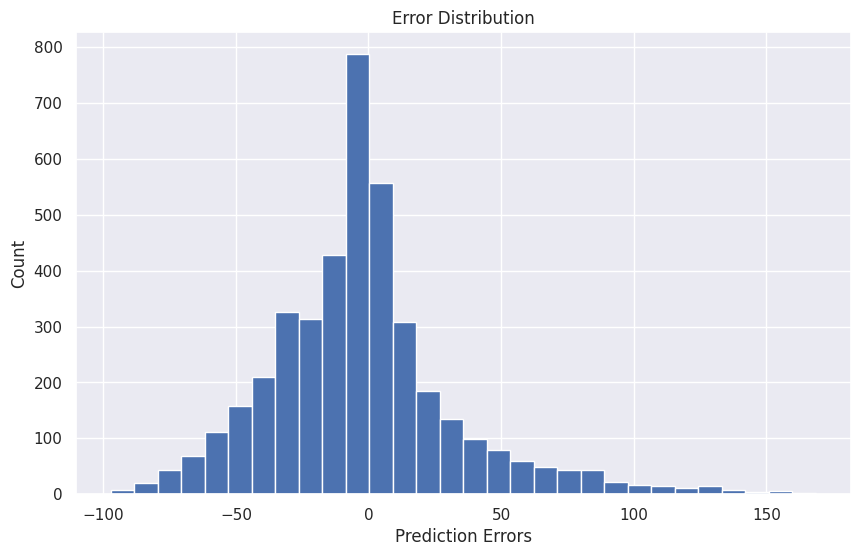

In [141]:
errors = y_test - y_pred_rf

plt.figure(figsize= (10,6))

plt.hist(
    errors,
    bins = 30
)

plt.xlabel("Prediction Errors")
plt.ylabel("Count")

plt.title("Error Distribution")
plt.show()

### **3 — Feature Importance**

In [142]:
importance = pd.DataFrame(
    {
        "Feature" : X_train.columns,
        "Importance" : rf_model.feature_importances_
    }
)
importance

,Feature,Importance
0,cycle,0.539977
1,setting_1,0.015781
2,setting_2,0.009535
3,sensor_2,0.019089
4,sensor_3,0.018950
5,sensor_4,0.039765
6,sensor_6,0.000529
7,sensor_7,0.023563
8,sensor_8,0.014497
9,sensor_9,0.042552


In [143]:
importance = importance.sort_values(by = 'Importance', ascending= False)
importance

,Feature,Importance
0,cycle,0.539977
10,sensor_11,0.141879
9,sensor_9,0.042552
5,sensor_4,0.039765
11,sensor_12,0.032108
13,sensor_14,0.024544
7,sensor_7,0.023563
14,sensor_15,0.021191
17,sensor_21,0.020496
3,sensor_2,0.019089


### **4 — Visualize Top Sensors**

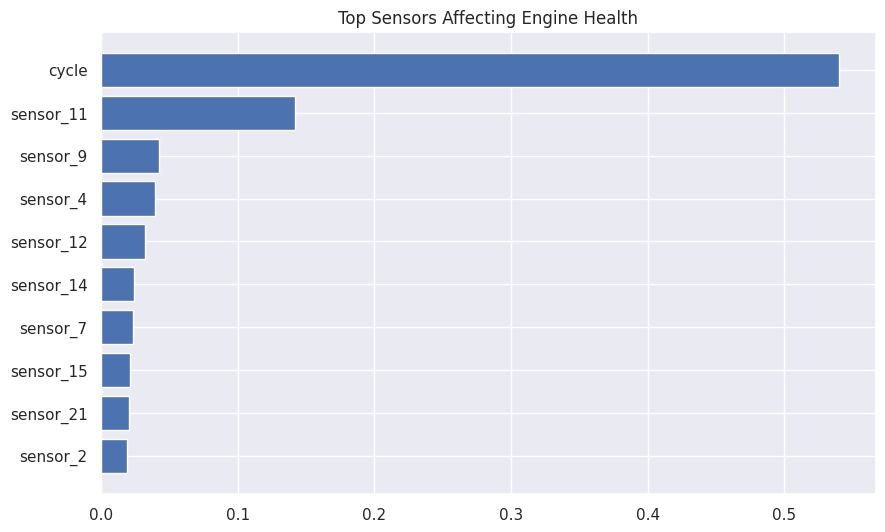

In [144]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.title("Top Sensors Affecting Engine Health")

plt.show()

### **5 — Convert RUL into Maintenance Decision**

In [145]:
def maintenance_alert(rul):

    if rul < 20:
        return "Immediate Maintenance"

    elif rul < 50:
        return "Schedule Maintenance"

    else:
        return "Healthy"


sample = y_pred_rf[:10]

for value in sample:
    print(
        round(value),
        maintenance_alert(value)
    )

110 Healthy
9 Immediate Maintenance
202 Healthy
1 Immediate Maintenance
120 Healthy
114 Healthy
117 Healthy
81 Healthy
103 Healthy
144 Healthy


Random Forest achieved lower prediction error than Linear Regression and identified key sensor measurements contributing to engine degradation. Predicted RUL was converted into actionable maintenance categories.

# Section 5: Hyperparameter Tuning + Validation

### **1 — Create Baseline Record**

Before tuning, note current metrics.

In [146]:
baseline_mae = mae_rf
baseline_rmse = mse_rf
baseline_r2 = r2

print("Baseline R2:", baseline_r2)

Baseline R2: 0.7173700821322665


### **2 — Hyperparameter Tuning (Random Forest)**

Think of hyperparameter tuning as:

> “Trying different settings of the model automatically and selecting the best one.”


Grid Search trained many Random Forest models and compared them.

In [147]:
# Create combinations

param_grid = {
    "n_estimators": [100, 200],  # 2 parameters   - Number of trees
    "max_depth": [10, 20, None], # 3 parameters   - How deep each tree can grow. None → unlimited depth
    "min_samples_split": [2, 5], # 2 parameters   - Minimum rows needed to split
    "min_samples_leaf": [1, 2]   # 2 parameters   - Minimum rows in final leaf
}

# 2 * 3 * 2 * 2 = 24 models

In [148]:
grid = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),
    param_grid=param_grid,
    cv=3,                     # every model trained 3 times.
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

#  cv (cross validation) = 3. Every model trained ont once, but 3 times
#  24 * 3 = 72 models

In [149]:
grid.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2', verbose=2)

### **3 — Get Best Parameters**

In [150]:
print(f"Best params: {grid.best_params_}")
print(f"Best scores: {grid.best_score_}")

Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best scores: 0.7264624878982028


**Pick highest R²**

Grid Search compared all averages.

Winner:

max_depth=None

min_samples_leaf=1

min_samples_split=2

n_estimators=200

### **4 — Evaluate Tuned Model**

In [151]:
best_rf = grid.best_estimator_

# best_rf retrained using best settings.

y_pred_tuned = best_rf.predict(X_test)

In [152]:
mae_tuned = mean_absolute_error(y_test,y_pred_tuned)
mse_tuned = np.sqrt(mean_squared_error(y_test,y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Tuned Model MAE: {mae_tuned}")
print(f"Tuned Model MSE: {mse_tuned}")
print(f"Tuned Model R2 Score: {r2_tuned}")

Tuned Model MAE: 25.23736529360988
Tuned Model MSE: 35.57701727194526
Tuned Model R2 Score: 0.7229632488589848


### **5 — Cross Validation**



This checks model stability.

To evaluate model stability, 5-fold cross validation was performed.

The training data was divided into five folds. In each iteration, four folds were used for training and one fold for validation.

The low variation across folds indicates that the model generalizes well and maintains consistent predictive performance.

In [153]:
scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print(scores)
print(scores.mean())

[0.73668037 0.71171183 0.72579206 0.73035193 0.7301605 ]
0.7269393369338581


In [154]:
X_train.columns

Index(['cycle', 'setting_1', 'setting_2', 'sensor_2', 'sensor_3', 'sensor_4',
       'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17',
       'sensor_20', 'sensor_21'],
      dtype='object')

### **6 — Compare Before vs After**

In [155]:
comparison = pd.DataFrame({
    "Metric": ["MAE","RMSE","R2"],
    "Before":[baseline_mae,baseline_rmse,baseline_r2],
    "After":[mae_tuned,mse_tuned,r2_tuned]
})

print(comparison)

  Metric     Before      After
0    MAE  25.450434  25.237365
1   RMSE  35.934359  35.577017
2     R2   0.717370   0.722963


# **Final Business Insights**


### **Key Findings:**
- Engine degradation increases with operating cycles.
- Random Forest captured nonlinear degradation patterns.
- Feature importance showed the strongest influence from engineered health indicators.
- Hyperparameter tuning improved model robustness.
- Cross-validation confirmed consistent performance.

### **7 — Save Final Model**

**joblib** is used to save trained machine learning models into a file so you can reuse them later.

The final tuned Random Forest model was stored using joblib.

This allows reuse of the trained model without retraining, reducing execution time and enabling deployment into production applications.

In [156]:
joblib.dump(
    best_rf,
    "predictive_maintenance_model.pkl"
)

['predictive_maintenance_model.pkl']

In [157]:
model = joblib.load(
    "predictive_maintenance_model.pkl"
)